#  EDA — student_habits_performance

This notebook  expands the exploratory data analysis (EDA) with more visualizations, checks, and brief insights.



---


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Matplotlib inline is useful for notebooks; plotting defaults are left standard.
%matplotlib inline

print('Libraries imported')

Libraries imported


In [ ]:
#  Load dataset
path = 'student_habits_performance.csv'
try:
    df = pd.read_csv(path)
    print('Loaded', path)
except Exception as e:
    print('Could not load', path, '— please ensure the CSV is in the same folder as the notebook.\nError:', e)

# Quick peek
df.head()

Loaded /content/student_habits_performance.csv


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
#  Basic info & missing values
print('Shape:', df.shape)
print('\nColumns and dtypes:')
print(df.dtypes)




Shape: (1000, 16)

Columns and dtypes:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object


In [9]:
# Identify numeric and categorical columns

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)

cat_candidates = df.select_dtypes(include=['object','category']).columns.tolist()
print('Categorical candidates:', cat_candidates)

Numeric columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical candidates: ['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [10]:
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


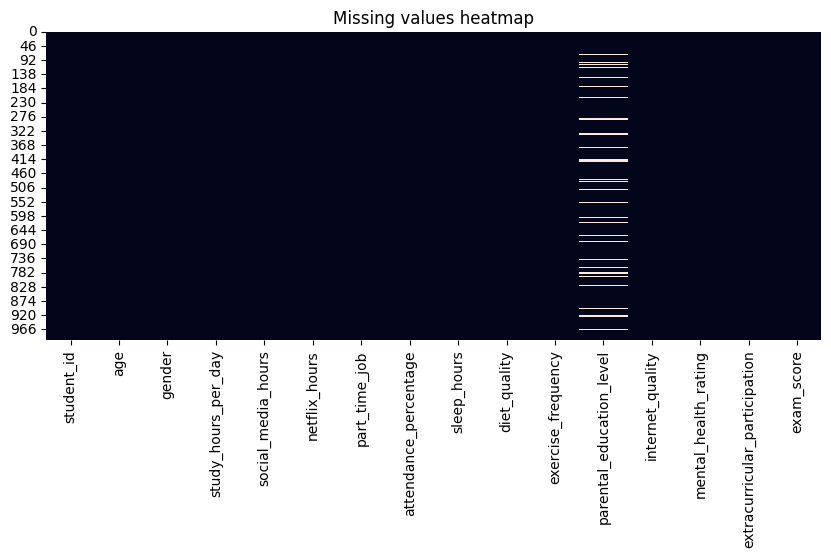

In [11]:

# Visualize missing values heatmap
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing values heatmap')
plt.show()

## Filling the missing value

In [12]:
# Optional: fill missing numeric with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Optional: fill categorical with mode
for c in cat_candidates:
    df[c] = df[c].fillna(df[c].mode()[0])

##  Summary statistics
Numeric summary and a quick check for skewness/outliers

In [13]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


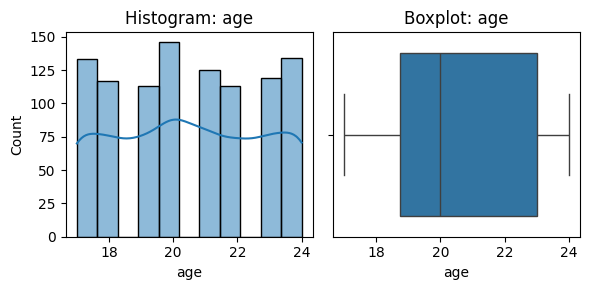

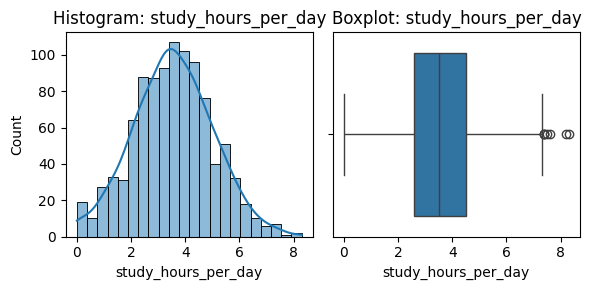

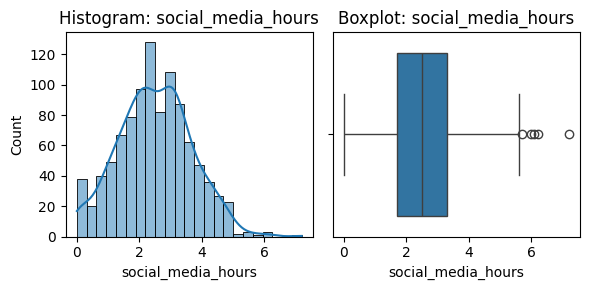

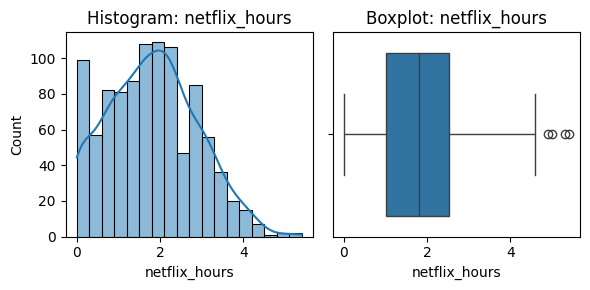

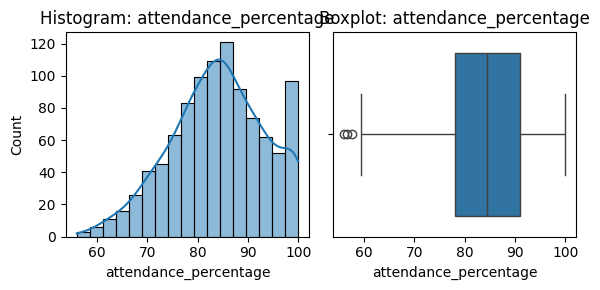

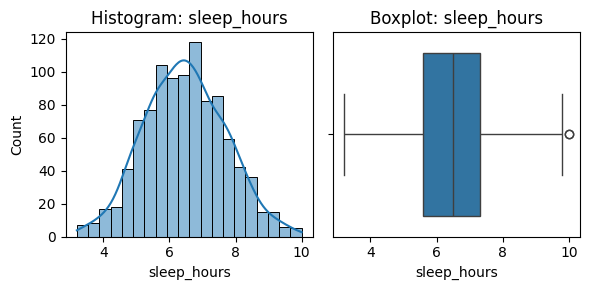

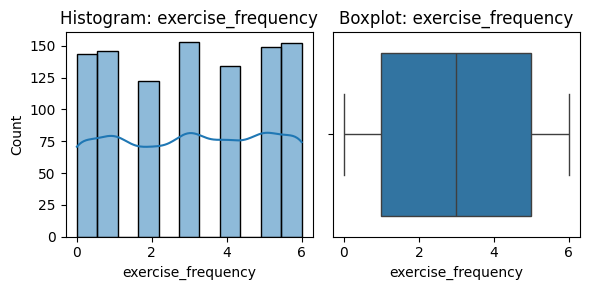

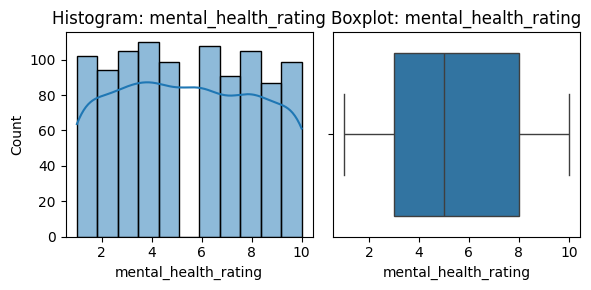

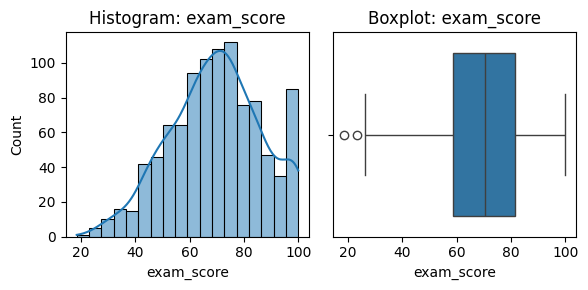

In [14]:
#  Univariate analysis: distributions for numeric columns
for c in num_cols:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(f'Histogram: {c}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[c].dropna())
    plt.title(f'Boxplot: {c}')

    plt.tight_layout()
    plt.show()

## Categorical variable counts
Countplots for key categorical columns (if present).

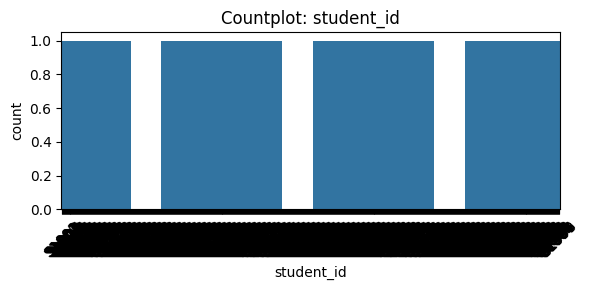

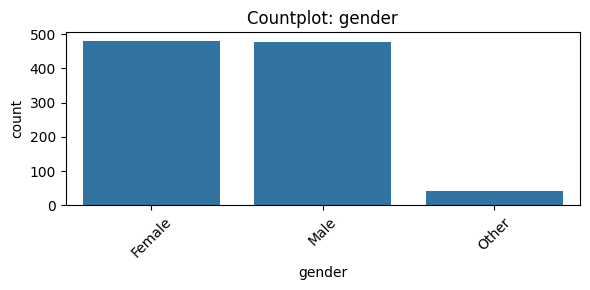

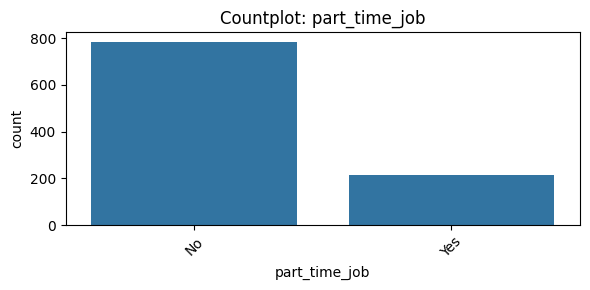

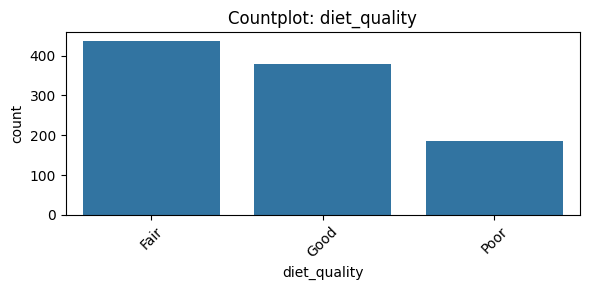

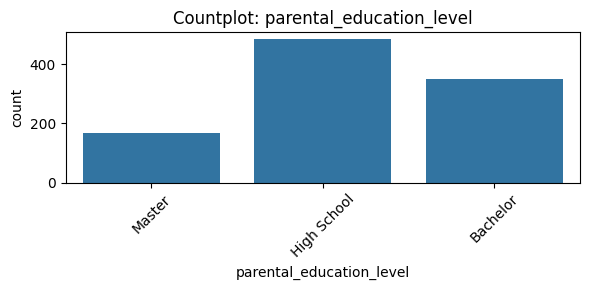

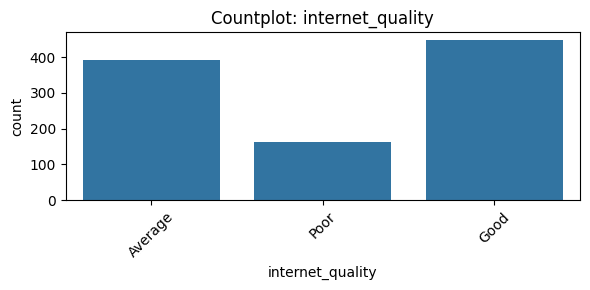

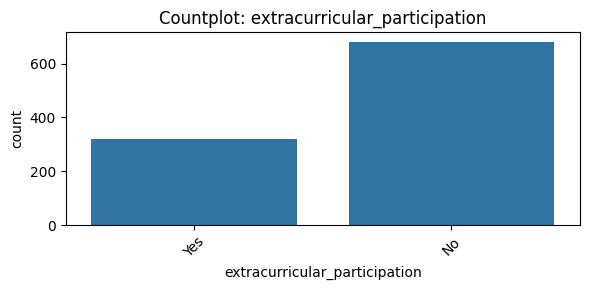

In [15]:
for c in cat_candidates:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=c)
    plt.title(f'Countplot: {c}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Bivariate analysis
Correlation heatmap, pairplot sample, and specific boxplots to compare study habits and performance.

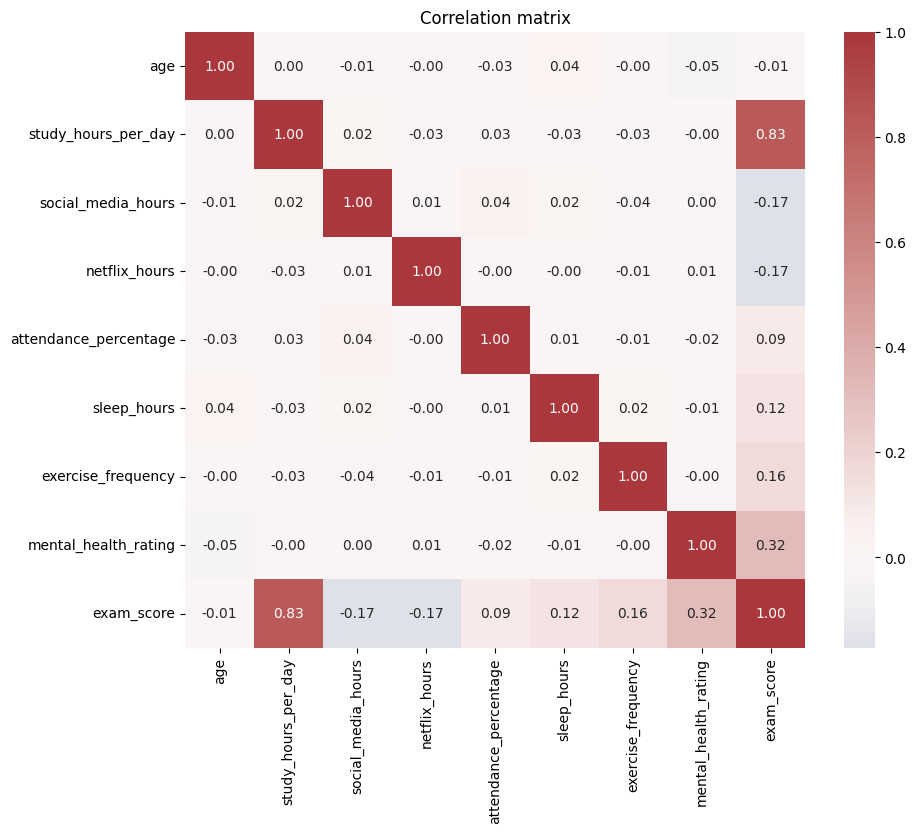

In [20]:
# Correlation matrix for numeric vars
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation matrix')
plt.show()


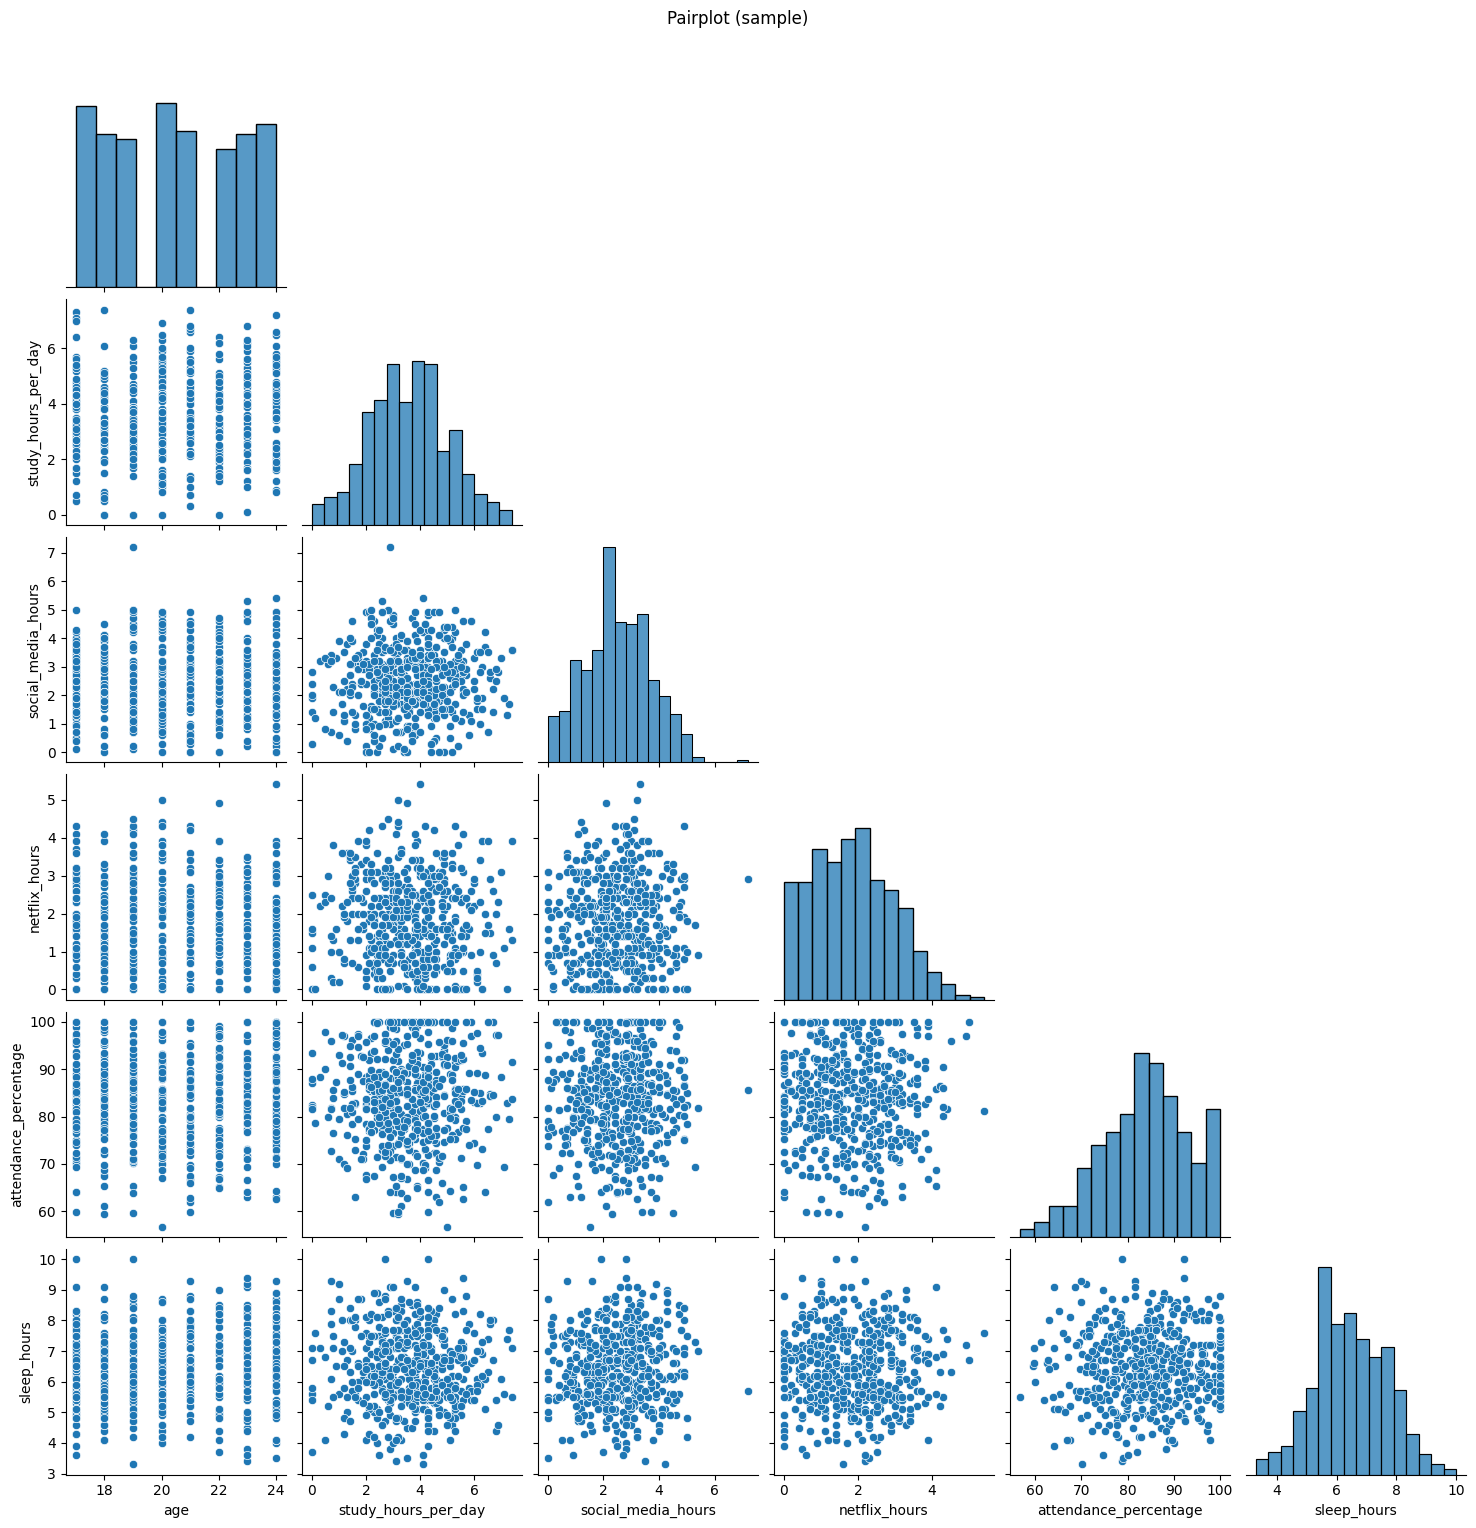

In [21]:

# Pairplot on a trimmed set (to keep it readable)
pp_cols = num_cols[:6] if len(num_cols) > 6 else num_cols
if len(pp_cols) > 1:
    sns.pairplot(df[pp_cols].dropna().sample(min(500, len(df))), corner=True)
    plt.suptitle('Pairplot (sample)', y=1.02)
    plt.show()
else:
    print('Not enough numeric columns for a pairplot.')

# Outlier detection (IQR method) for numeric columns

In [18]:
outliers_summary = {}
for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0 or np.isnan(IQR):
        outliers_summary[c] = 0
        continue
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    count = df[(df[c] < low) | (df[c] > high)].shape[0]
    outliers_summary[c] = int(count)

outliers_summary

{'age': 0,
 'study_hours_per_day': 7,
 'social_media_hours': 5,
 'netflix_hours': 4,
 'attendance_percentage': 3,
 'sleep_hours': 2,
 'exercise_frequency': 0,
 'mental_health_rating': 0,
 'exam_score': 2}

## Quick insights & next steps
- Look at correlations above to identify strong relationships.
- Consider running a regression or classification model to measure predictive power of habits on performance.
- Clean or transform highly skewed numeric columns (log, box-cox) if planning modelling.

---

*Notebook generated automatically — review columns and adjust the column-name heuristics where necessary.*

In [19]:
# Save a small CSV snapshot of cleaned/usable data if needed
snapshot_path = 'clean_student_habits.csv'
try:
    df.to_csv(snapshot_path, index=False)
    print('Snapshot saved to', snapshot_path)
except Exception as e:
    print('Could not save snapshot:', e)

Snapshot saved to studdata_enhanced_snapshot.csv
